In [2]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import pandas as pd
import numpy as np
import json
import sys
sys.path.append("src")

from fusion.late_fusion import run_fusion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data/processed/labels.csv")
print(f"Dataset: {df.shape}")

Dataset: (4869, 4)


In [4]:
# Reproducir el mismo split que usaron los módulos
le     = LabelEncoder()
labels = le.fit_transform(df['label'].tolist())
texts  = df['text'].tolist()

_, _, _, y_test = train_test_split(
    texts, labels,
    test_size=0.2, random_state=42, stratify=labels)

print(f"Test set: {len(y_test)} muestras")
print(f"Clases: {le.classes_}")

Test set: 974 muestras
Clases: ['negative' 'neutral' 'positive']


In [5]:
# Fusión con 5 módulos incluyendo RoBERTa LLM
from fusion.late_fusion import load_probas, simulated_annealing
from sklearn.metrics import classification_report, f1_score

paths = [
    'results/metrics_nlp_classic.json',
    'results/metrics_bert.json',
    'results/metrics_cv_classic.json',
    'results/metrics_resnet.json',
    'results/metrics_llm.json'
]

probas_list = [load_probas(p) for p in paths]
n           = min(len(p) for p in probas_list)
probas_list = [p[:n] for p in probas_list]
y           = y_test[:n]

# Optimizar con SA — ahora 5 módulos
best_weights, best_f1, history = simulated_annealing(
    probas_list, y)

best_weights_norm = best_weights / best_weights.sum()
fusion = sum(w * p for w, p in zip(best_weights_norm, probas_list))
preds  = np.argmax(fusion, axis=1)

print("\n=== Late Fusion 5 módulos (SA) ===")
print(classification_report(y, preds, target_names=le.classes_))
print(f"F1 macro: {best_f1:.4f}")

labels_sa = ['LR', 'BERT', 'SVM', 'ResNet', 'RoBERTa']
print("\nPesos óptimos:")
for l, w in zip(labels_sa, best_weights_norm):
    print(f"  {l}: {w:.3f}")

# Actualizar variables para las celdas siguientes
f1           = best_f1
best_weights = best_weights_norm

Simulated Annealing iniciado
T0=1.0 · Tf=0.001 · alpha=0.95
F1 inicial (pesos iguales): 0.7232

SA completado en 135 iteraciones
Pesos óptimos encontrados:
  LR: 0.344
  BERT: 0.299
  SVM: 0.277
  ResNet: 0.000
Mejor F1: 0.7486

=== Late Fusion 5 módulos (SA) ===
              precision    recall  f1-score   support

    negative       0.72      0.74      0.73       244
     neutral       0.74      0.74      0.74       384
    positive       0.78      0.77      0.77       346

    accuracy                           0.75       974
   macro avg       0.75      0.75      0.75       974
weighted avg       0.75      0.75      0.75       974

F1 macro: 0.7486

Pesos óptimos:
  LR: 0.344
  BERT: 0.299
  SVM: 0.277
  ResNet: 0.000
  RoBERTa: 0.080


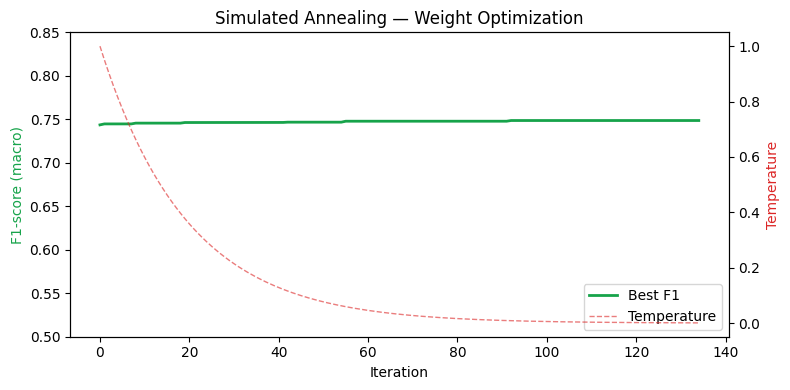

Gráfica guardada en results/figures/sa_convergence.png


In [12]:
# Gráfica de convergencia del SA
import matplotlib.pyplot as plt

temps   = [h['T'] for h in history]
f1_hist = [h['best_f1'] for h in history]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(f1_hist, color='#16a34a', linewidth=2, label='Best F1')
ax2.plot(temps,   color='#dc2626', linewidth=1,
         linestyle='--', alpha=0.6, label='Temperature')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('F1-score (macro)', color='#16a34a')
ax2.set_ylabel('Temperature', color='#dc2626')
ax1.set_title('Simulated Annealing — Weight Optimization')
ax1.set_ylim(0.5, 0.85)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.savefig('results/figures/sa_convergence.png', dpi=150)
plt.show()
print("Gráfica guardada en results/figures/sa_convergence.png")

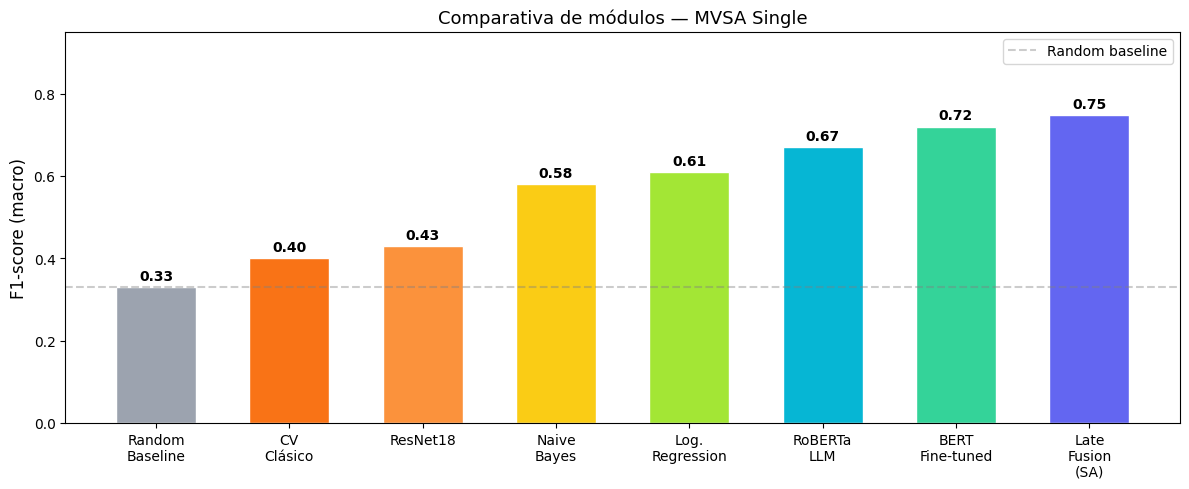

In [9]:
modulos   = ['Random\nBaseline', 'CV\nClásico', 'ResNet18',
             'Naive\nBayes', 'Log.\nRegression', 'RoBERTa\nLLM',
             'BERT\nFine-tuned', 'Late\nFusion\n(SA)']
f1_scores = [0.33, 0.40, 0.43, 0.58, 0.61, 0.67, 0.72, f1]
colors    = ['#9ca3af', '#f97316', '#fb923c',
             '#facc15', '#a3e635', '#06b6d4',
             '#34d399', '#6366f1']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(modulos, f1_scores, color=colors,
              width=0.6, edgecolor='white')

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 0.95)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('Comparativa de módulos — MVSA Single', fontsize=13)
ax.axhline(y=0.33, color='gray', linestyle='--',
           alpha=0.4, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/fusion_comparison.png', dpi=150)
plt.show()

In [11]:
results_final = {
    'f1_macro': f1,
    'best_weights': {
        'LR':      float(best_weights[0]),
        'BERT':    float(best_weights[1]),
        'SVM':     float(best_weights[2]),
        'ResNet':  float(best_weights[3]),
        'RoBERTa': float(best_weights[4])
    },
    'method': 'Simulated Annealing',
    'sa_params': {
        'T0': 1.0, 'Tf': 0.001,
        'alpha': 0.95, 'max_iter': 500
    }
}

with open('results/metrics_fusion_sa.json', 'w') as f:
    json.dump(results_final, f, indent=2)

print("Guardado en results/metrics_fusion_sa.json")
print(f"\nResumen final:")
print(f"  F1 macro: {f1:.4f}")
labels_sa = ['LR', 'BERT', 'SVM', 'ResNet', 'RoBERTa']
for l, w in zip(labels_sa, best_weights):
    print(f"  {l}: {w:.3f}")

Guardado en results/metrics_fusion_sa.json

Resumen final:
  F1 macro: 0.7486
  LR: 0.344
  BERT: 0.299
  SVM: 0.277
  ResNet: 0.000
  RoBERTa: 0.080
